In [18]:
import pandas as pd

df = pd.read_csv("D:\VsCode\superstore-analytics-project\data\superstore_raw.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [19]:
df.shape

(9994, 21)

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [22]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [23]:
df["profit_margin"] = df["Profit"] / df["Sales"]

df["ship_delay_days"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [24]:
df[["Order Date","Ship Date","ship_delay_days"]].head()

,Order Date,Ship Date,ship_delay_days
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7


In [26]:
print("Dataset shape:", df.shape)
print("Total Sales:", df["Sales"].sum())
print("Total Profit:", df["Profit"].sum())

Dataset shape: (9994, 23)
Total Sales: 2297200.8603
Total Profit: 286397.0217


In [27]:
df["profit_margin"] = df["Profit"] / df["Sales"]

df["ship_delay_days"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [28]:
df[["Profit","Sales","profit_margin","ship_delay_days"]].head()

,Profit,Sales,profit_margin,ship_delay_days
0,41.9136,261.9600,0.1600,3
1,219.5820,731.9400,0.3000,3
2,6.8714,14.6200,0.4700,4
3,-383.0310,957.5775,-0.4000,7
4,2.5164,22.3680,0.1125,7


In [29]:
print("Dataset shape:", df.shape)
print("Total Sales:", df["Sales"].sum())
print("Total Profit:", df["Profit"].sum())

Dataset shape: (9994, 23)
Total Sales: 2297200.8603
Total Profit: 286397.0217


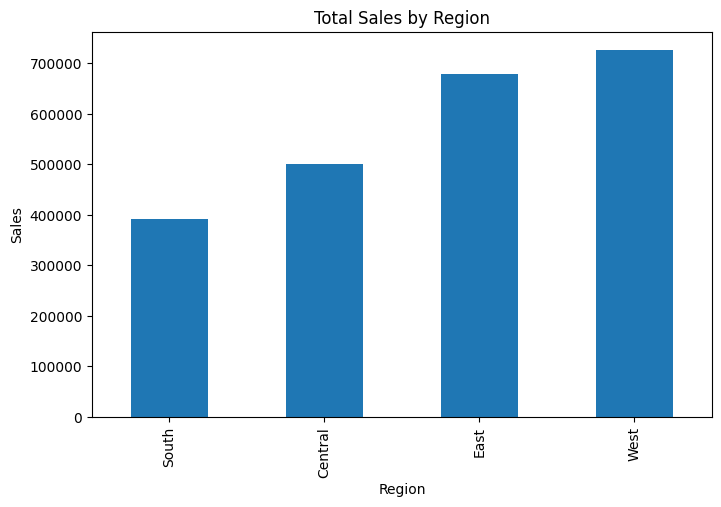

In [30]:
import matplotlib.pyplot as plt

region_sales = df.groupby("Region")["Sales"].sum().sort_values()

plt.figure(figsize=(8,5))
region_sales.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

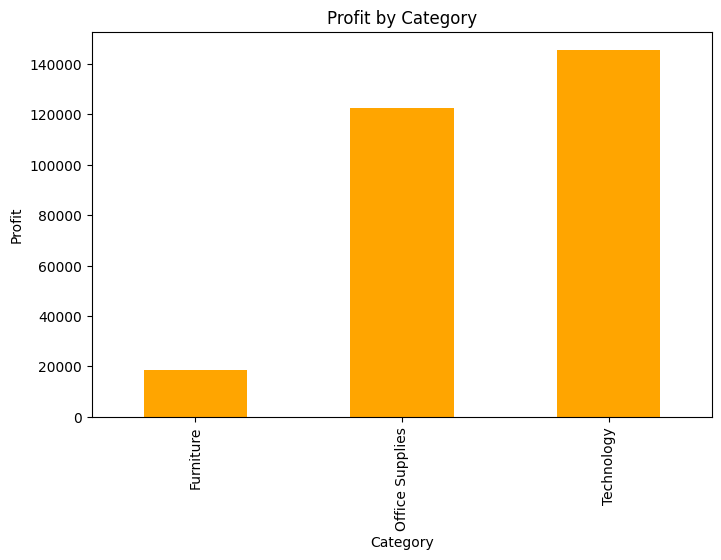

In [31]:
category_profit = df.groupby("Category")["Profit"].sum()

plt.figure(figsize=(8,5))
category_profit.plot(kind="bar", color="orange")

plt.title("Profit by Category")
plt.ylabel("Profit")

plt.show()

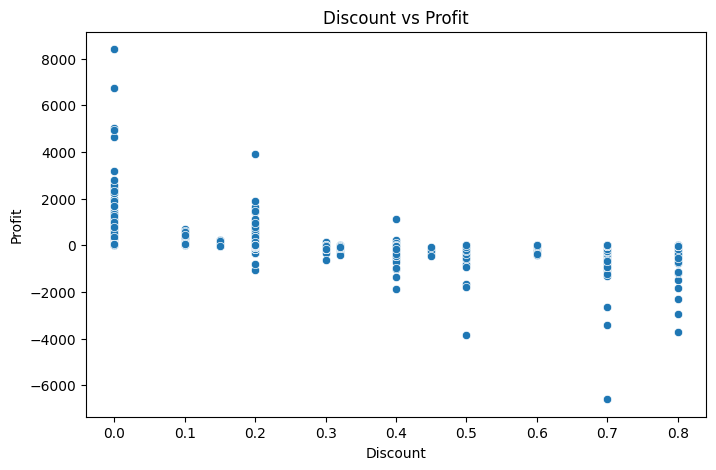

In [32]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Discount", y="Profit")

plt.title("Discount vs Profit")
plt.show()


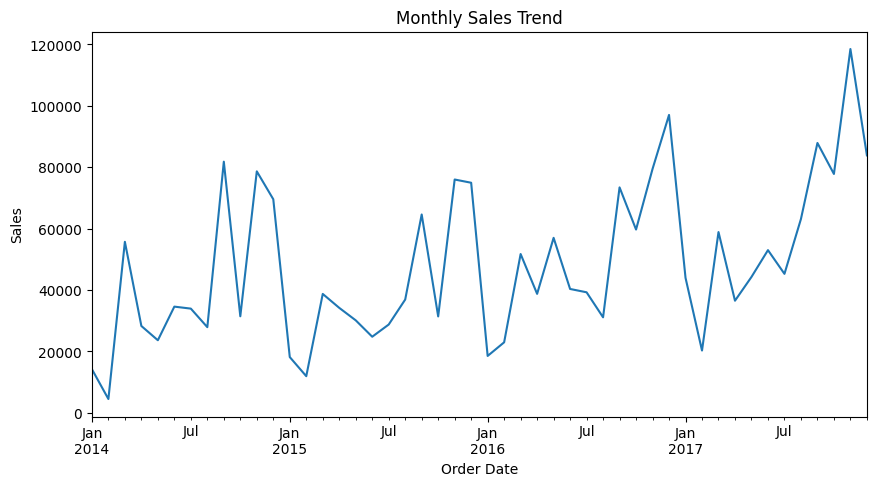

In [33]:
monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()

monthly_sales.plot(figsize=(10,5))

plt.title("Monthly Sales Trend")
plt.ylabel("Sales")

plt.show()

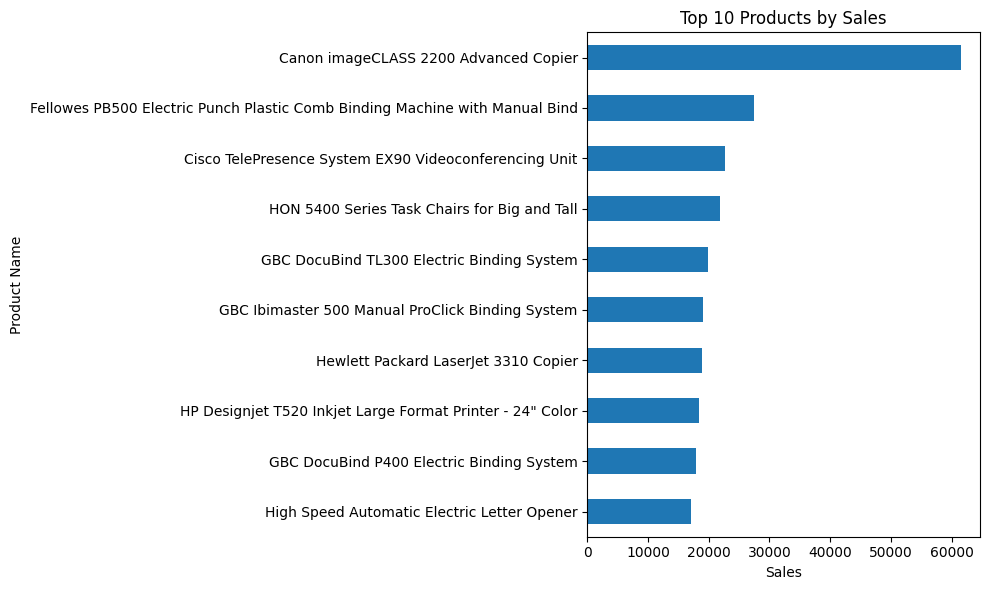

In [34]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=True).tail(10)

plt.figure(figsize=(10,6))
top_products.plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")

plt.tight_layout()

plt.show()

In [36]:
df.to_csv("D:\VsCode\superstore-analytics-project\data\superstore_clean.csv", index=False)